In [2]:
import pandas as pd
import torch
import numpy as np
import matplotlib.pyplot as plt
import wfdb
import os
from utils import get_ecg
import sys
from tqdm import tqdm

In [ ]:
example_path = "/MedalCare-XL/MedalCare-XL/WP2_largeDataset_Noise/avblock/train/run_S65"

In [3]:
with open(f"{example_path}/run_000001_filtered.csv", 'r') as f:
    content = f.read()

In [4]:
lead_strs = [lead for lead in content.strip().split('\n')]

In [5]:
leads = [list(map(float, lead_str.strip().split(','))) for lead_str in lead_strs]

#lead order: I, II, III, aVR, aVL, aVF, V1-V6

In [6]:
def plot_ecg(data, leads_to_plot=None, tags = ['I', 'II', 'III'], sample_rate = 500):
    """
    Plots ECG data from a PyTorch tensor.
    
    Args:
        data: 12 lead ecg in shape (length_lead x n_leads)
        leads_to_plot: Which ones we want to be plotted
        tags: vector with all the possible lead names for this type of ecg
        sample_rate (int): Sampling rate in Hz (default is 500 Hz).
    """

    if not isinstance(data, torch.Tensor):
        raise ValueError("Input data must be a PyTorch tensor.")
    if data.ndim != 2 or data.shape[1] < 1:
        raise ValueError("Input tensor must have shape [n_samples, n_leads].")
    

    n_leads, n_samples = data.shape
    
    # Validate lead indices
    for lead in leads_to_plot:
        if lead not in tags:
            raise ValueError(f"Lead index {lead} is out of range for data tag leads.")
    
    # Create time axis
    time = torch.arange(n_samples) / sample_rate
    
    # Plot each selected lead
    plt.figure(figsize=(12, len(leads_to_plot) * 2))

    for i, lead_name in enumerate(leads_to_plot):
        plt.subplot(len(leads_to_plot), 1, i + 1)

        #Check the index correspondent to the lead we are selecting
        for lead_index in range(len(tags)):
            if tags[lead_index] == lead_name:
                break
        plt.plot(time, data[lead_index], label=f"Lead {lead_name}")
        plt.xlabel("Time (s)")
        plt.ylabel("Amplitude")
        plt.legend(loc="upper right")
        plt.grid(True)
    
    plt.tight_layout()
    plt.show()

In [7]:
leads_labels = ["I", "II", "III", "aVR", "aVL", "aVF", "V1", "V2", "V3", "V4", "V5", "V6"]

ecg_array = np.array(leads)

if ecg_array.shape[0] == 12:
    ecg_array = ecg_array.T


record = (ecg_array, {"sig_name": leads_labels})

# Create the dataframe
df = pd.DataFrame(record[0], columns=record[1]["sig_name"])

In [ ]:
record_name = 'my-ecg-record'
dir_save = './medalcare_XL_filtered'
wfdb.wrsamp(
    record_name = record_name,
    fs = 500,  # Set your actual sampling rate here
    units = ['mV'] * 12,
    sig_name = leads_labels,
    p_signal = ecg_array,
    fmt = ['16'] * 12,  # 16-bit integer format
    write_dir= dir_save
)

In [9]:
ecgs = get_ecg(input_path = os.path.join(dir_save, f"{record_name}"), data_aug_flag= False, leads_labels = leads_labels, dataset_name = "medalcare")

In [ ]:
#Plot the ecg data
plot_ecg(torch.tensor(ecgs), leads_to_plot=['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6'], tags=leads_labels, sample_rate=500)

In [ ]:
# Open and convert file into wfdb format

def convert_to_wfdb_format(input_dir, file, name, output_dir):
    
    with open(f"{input_dir}/{file}", 'r') as f:
        content = f.read()

    lead_strs = [lead for lead in content.strip().split('\n')]

    leads = [list(map(float, lead_str.strip().split(','))) for lead_str in lead_strs]
    leads_labels = ["I", "II", "III", "aVR", "aVL", "aVF", "V1", "V2", "V3", "V4", "V5", "V6"]  
    ecg_array = np.array(leads)
    
    if ecg_array.shape[0] == 12:
        ecg_array = ecg_array.T
    
    record = (ecg_array, {"sig_name": leads_labels})
    # Create the dataframe
    df = pd.DataFrame(record[0], columns=record[1]["sig_name"])

    record_name = name
    
    wfdb.wrsamp(
        record_name = record_name,
        fs = 500,  # Set your actual sampling rate here
        units = ['mV'] * 12,
        sig_name = leads_labels,
        p_signal = ecg_array,
        fmt = ['16'] * 12,  # 16-bit integer format
        write_dir= output_dir
    )


    

In [ ]:
# List directories 


leads_labels = ["I", "II", "III", "aVR", "aVL", "aVF", "V1", "V2", "V3", "V4", "V5", "V6"]
input_root = "/mnt/l/ECG_datasets/MedalCare-XL/MedalCare-XL/WP2_largeDataset_Noise"

conditions = ['avblock', 
              'fam', 
              'iab', 
              'lae', 
              'lbbb', 
              'mi/LAD_0.3',
              'mi/LAD_1.0', 
              'mi/LCX_0.3_ant', 
              'mi/LCX_0.3_post',
              'mi/LCX_1.0_ant',
              'mi/LCX_1.0_post',
              'mi/RCA_0.3',
              'mi/RCA_1.0',
              'rbbb', 
              'sinus']


#Which folders are we concatenating: training, validation or test 
#We will get all the examples of a split from all classes, convert into rdam format and save in a new folder
mode = 'test'


save_dir = '/medalcare_XL_filtered' + f'/{mode}'
print(conditions)

cnt = 0
#Loop over each condition folder
for condition in tqdm(conditions):


    condition_path = os.path.join(input_root, f"{condition}/{mode}")

    #Loop over each run of that condition
    for run in os.listdir(condition_path):
        
        run_dir = os.path.join(condition_path, run)

        #Loop over each filtered_file
        for file in os.listdir(run_dir):

            if file.endswith('_filtered.csv'):
                
                condition_name = condition 

                if condition_name[0:2] == 'mi':
                    condition_name = condition_name.replace('/', '_').replace('.','')

                name = f"{mode}_{condition_name}_{run}_{file.split('.')[0]}"
                #print(name)
                cnt+=1
                
                convert_to_wfdb_format(run_dir, file, name, save_dir)
                
            else:
                continue

print(cnt)


['avblock', 'fam', 'iab', 'lae', 'lbbb', 'mi/LAD_0.3', 'mi/LAD_1.0', 'mi/LCX_0.3_ant', 'mi/LCX_0.3_post', 'mi/LCX_1.0_ant', 'mi/LCX_1.0_post', 'mi/RCA_0.3', 'mi/RCA_1.0', 'rbbb', 'sinus']


100%|██████████| 15/15 [01:40<00:00,  6.73s/it]

2386


In [ ]:
# Create dataframes in csv format for label matching

mode = 'train'
root_dir = f'/medalcare_XL_filtered/{mode}'

# Ordered list of condition names
conditions = ['avblock', 'fam', 'iab', 'lae', 'lbbb', 'mi', 'rbbb', 'sinus']

# Create mapping: condition -> numeric label
condition_to_label = {cond: idx for idx, cond in enumerate(conditions)}

# List to hold records
records = []

for file in os.listdir(root_dir):
    if file.endswith('.dat'):
        file_name = file.split('.')[0]  # e.g., test_iab_run_S62_000082_filtered
        parts = file_name.split('_')    # ['test', 'iab', 'run', 'S62', ...]
        if len(parts) > 1:
            condition = parts[1]
            label = condition_to_label.get(condition)
            if label is not None:
                records.append({
                    'file_name': file_name,
                    'class': condition,
                    'label': label
                })

# Create DataFrame
df = pd.DataFrame(records)

# Preview result
print(df)
df.to_csv(f'{mode}_medalcare_labels.csv', index=False)
    

                                       file_name    class  label
0      train_avblock_run_S65_run_000001_filtered  avblock      0
1      train_avblock_run_S65_run_000002_filtered  avblock      0
2      train_avblock_run_S65_run_000003_filtered  avblock      0
3      train_avblock_run_S65_run_000004_filtered  avblock      0
4      train_avblock_run_S65_run_000005_filtered  avblock      0
...                                          ...      ...    ...
12017    train_sinus_run_S74_run_000096_filtered    sinus      7
12018    train_sinus_run_S74_run_000097_filtered    sinus      7
12019    train_sinus_run_S74_run_000098_filtered    sinus      7
12020    train_sinus_run_S74_run_000099_filtered    sinus      7
12021    train_sinus_run_S74_run_000100_filtered    sinus      7

[12022 rows x 3 columns]


/tmp/ipykernel_17213/2954414482.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  plot_ecg(torch.tensor(ecgs), leads_to_plot=['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6'], tags=leads_labels, sample_rate=500)


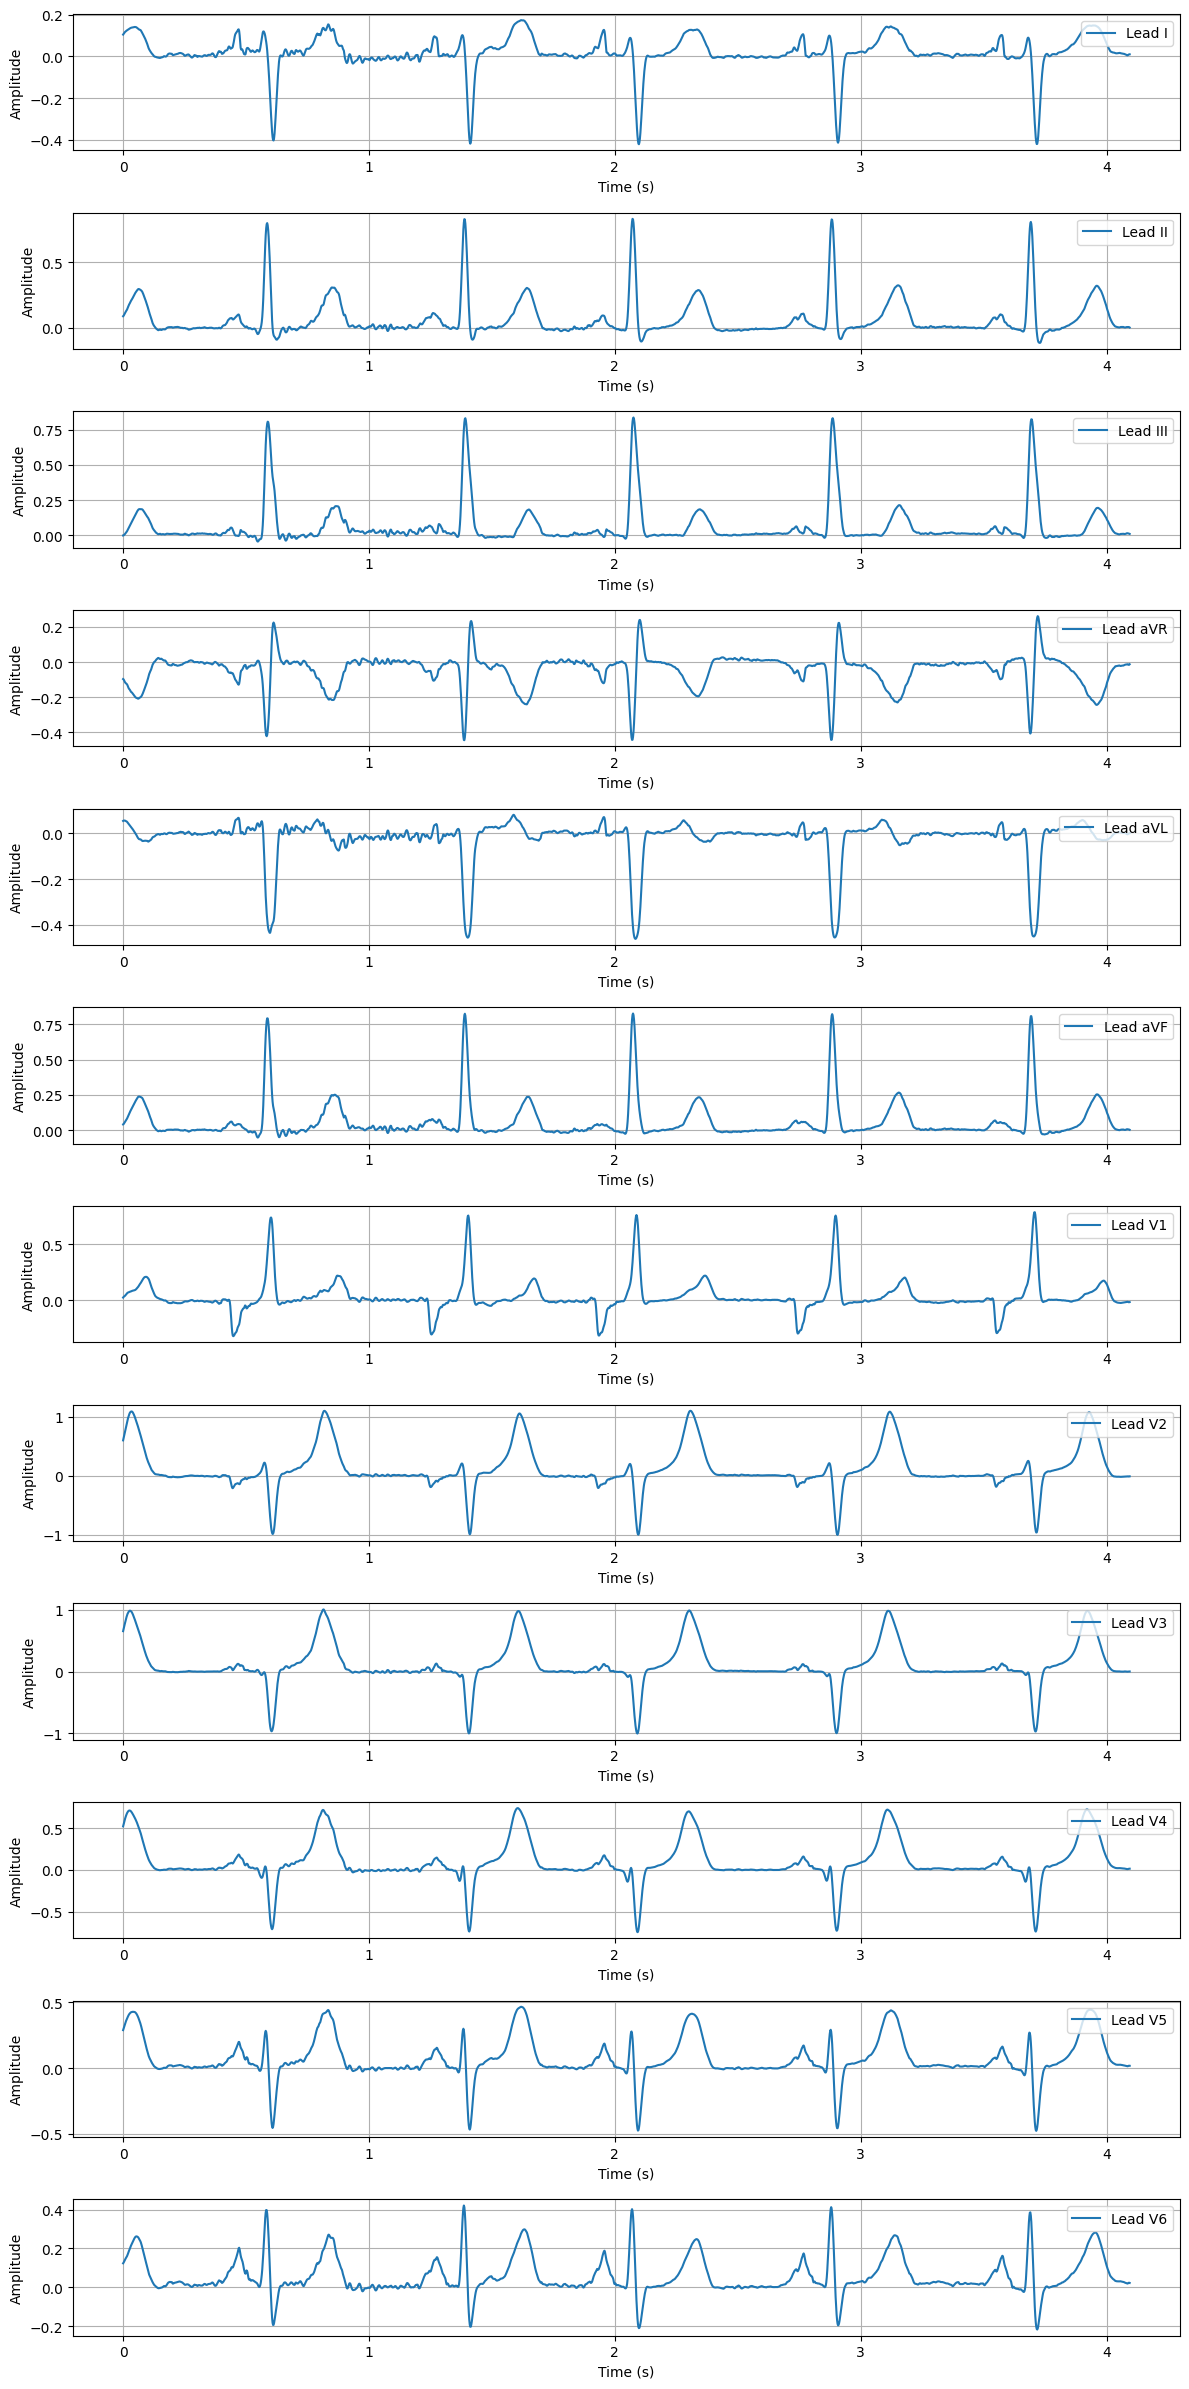

In [ ]:
record_name = "train_sinus_run_S74_run_000099_filtered"
input_path = '/medalcare_XL_filtered/train'

ecgs = get_ecg(input_path = os.path.join(input_path, record_name), data_aug_flag= False, leads_labels = leads_labels, dataset_name = "medalcare")
plot_ecg(torch.tensor(ecgs), leads_to_plot=['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6'], tags=leads_labels, sample_rate=500)

In [ ]:
#Check class distribution
database_file_path = 'cpsc18_dataset/labels.csv'
database = pd.read_csv(database_file_path, delimiter=',', header = 0)

#column 2 has the labels for each sample - they are str format so we need to convert to int
labels = database[database.columns[1:-1]].astype(int)

In [ ]:
class_counts = labels.sum(axis=0)
print(class_counts)

In [18]:
print(labels.value_counts().sort_index())
print(distribution.sum())

label
0     900
1    1040
2     994
3    1040
4     900
5    5350
6     898
7     900
Name: count, dtype: int64
12022
